# 01 - Dataset Visualization

Part 1 (prepare & visualize) of the course project pipeline. Downloads/caches
the KITTI subsets (object detection, semantics, optical flow) and visualizes
sample images with their native ground truth.

In [1]:
import os
import sys

IN_COLAB = "google.colab" in str(get_ipython())
REPO_URL = "https://github.com/Shir-Siman-Tov/Image-Processing-Project.git"
REPO_DIR = "/content/Image-Processing-Project"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
    else:
        # Runtime already had this repo cloned from an earlier cell run in this
        # session - pull so we don't keep running against a stale checkout.
        get_ipython().system(f"git -C {REPO_DIR} pull")
    os.chdir(REPO_DIR)
    get_ipython().system("pip install -q -e .")
    get_ipython().system("pip install -q -r requirements.txt")

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ipproj (pyproject.toml) ... done


## Load KITTI subsets

In [2]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from ipproj import config
from ipproj.datasets import kitti, kitti_flow
from ipproj.datasets.kitti import read_image
from ipproj.datasets.kitti_flow import read_kitti_flow_png
from ipproj.viz.plotting import plot_detection_boxes, plot_segmentation_mask, plot_image_grid, save_figure

detection_splits = kitti.load_object_detection_subset()
segmentation_splits = kitti.load_semantic_segmentation_subset()
flow_splits = kitti_flow.load_optical_flow_subset()

print("object_detection:", {k: len(v) for k, v in detection_splits.items()})
print("semantic_segmentation:", {k: len(v) for k, v in segmentation_splits.items()})
print("optical_flow:", {k: len(v) for k, v in flow_splits.items()})

data_object_image_2.zip: 100%|██████████| 12.6G/12.6G [06:29<00:00, 32.3MB/s]
data_object_label_2.zip: 100%|██████████| 5.60M/5.60M [00:00<00:00, 8.10MB/s]
data_semantics.zip: 100%|██████████| 328M/328M [00:10<00:00, 30.3MB/s]
data_scene_flow.zip: 100%|██████████| 1.68G/1.68G [00:51<00:00, 32.4MB/s]


object_detection: {'train': 350, 'val': 75, 'test': 75}
semantic_segmentation: {'train': 140, 'val': 30, 'test': 30}
optical_flow: {'train': 140, 'val': 30, 'test': 30}


## Sample grid: object detection ground truth


PosixPath('/content/Image-Processing-Project/figures/01_dataset_visualization/detection_gt_grid.png')

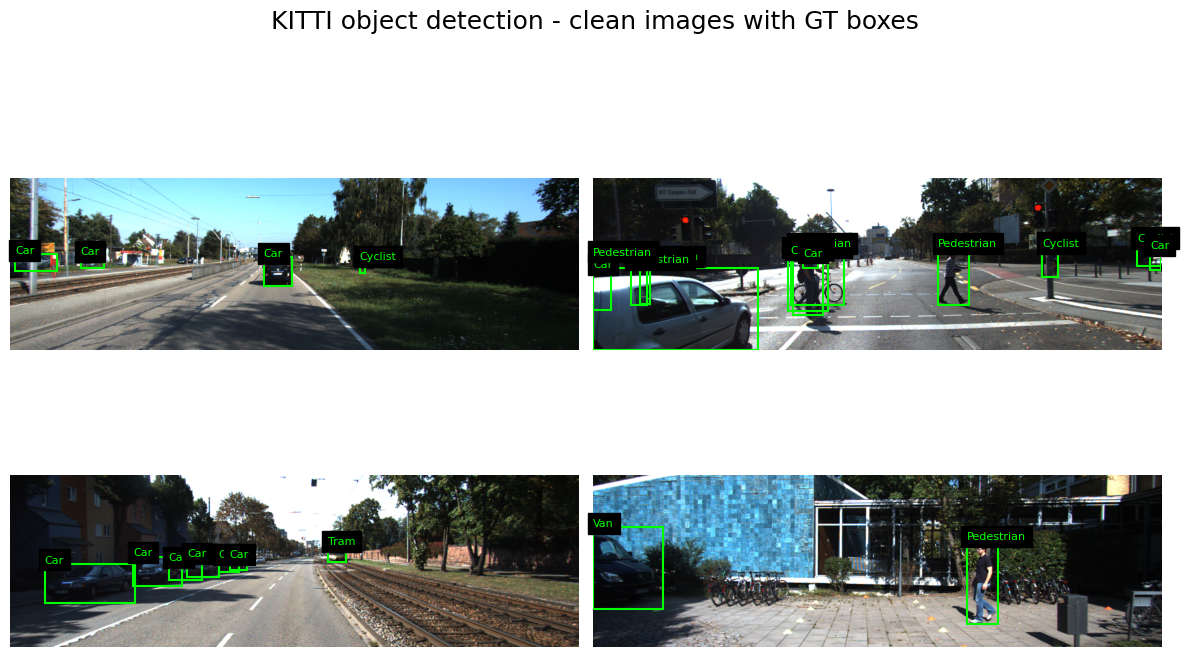

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, sample in zip(axes.flat, detection_splits["train"][:4]):
    image = read_image(sample.image_path)
    plot_detection_boxes(image, sample.boxes, sample.classes, ax=ax)
fig.suptitle("KITTI object detection - clean images with GT boxes", fontsize=18)
fig.tight_layout()
save_figure(fig, "01_dataset_visualization/detection_gt_grid.png")

## Sample grid: semantic segmentation ground truth

PosixPath('/content/Image-Processing-Project/figures/01_dataset_visualization/segmentation_gt_grid.png')

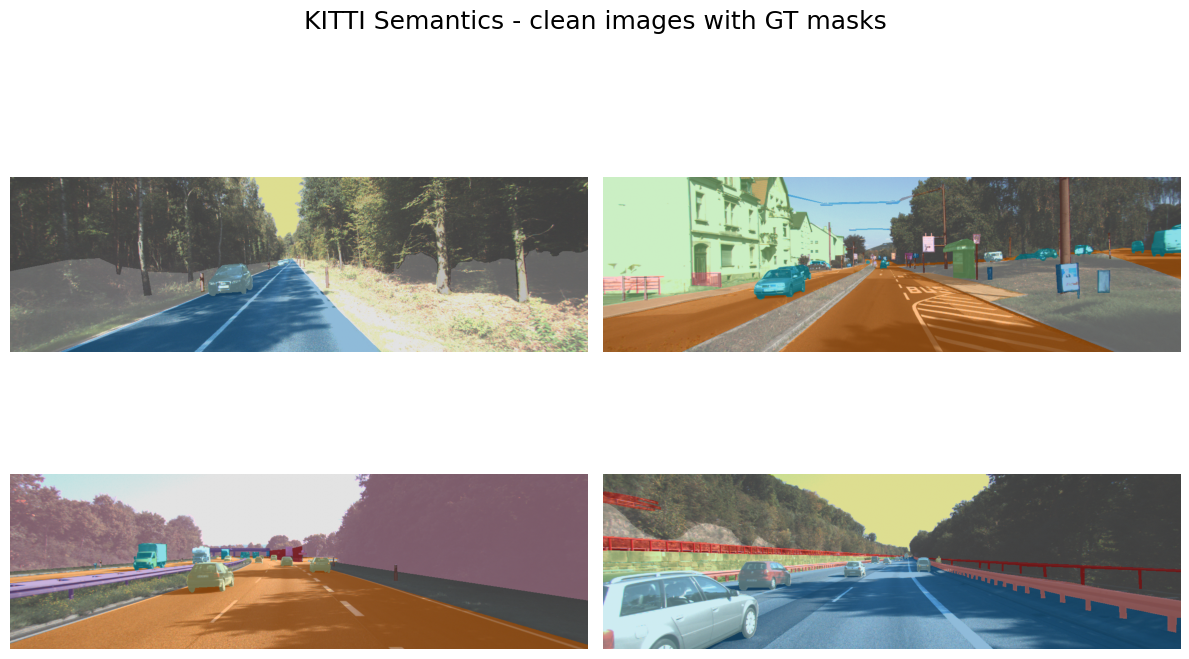

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, sample in zip(axes.flat, segmentation_splits["train"][:4]):
    image = read_image(sample.image_path)
    mask = cv2.imread(str(sample.mask_path), cv2.IMREAD_UNCHANGED)
    plot_segmentation_mask(image, mask, ax=ax)
fig.suptitle("KITTI Semantics - clean images with GT masks",fontsize = 18)
fig.tight_layout()
save_figure(fig, "01_dataset_visualization/segmentation_gt_grid.png")

## Sample pair: optical flow ground truth

PosixPath('/content/Image-Processing-Project/figures/01_dataset_visualization/optical_flow_gt.png')

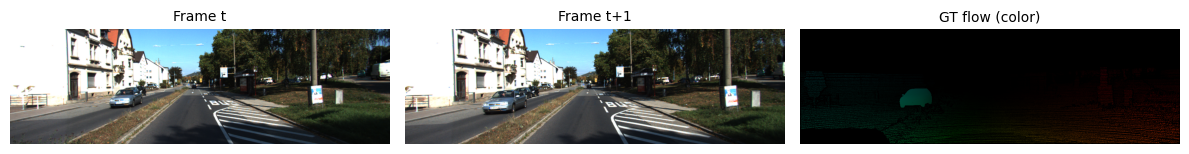

In [17]:
sample = flow_splits["train"][1]
frame1 = read_image(sample.frame1_path)
frame2 = read_image(sample.frame2_path)
flow, valid = read_kitti_flow_png(sample.flow_gt_path)

hsv = np.zeros_like(frame1)
hsv[..., 1] = 255
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
hsv[..., 0] = ang * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
flow_rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

fig = plot_image_grid([frame1, frame2, flow_rgb], titles=["Frame t", "Frame t+1", "GT flow (color)"], ncols=3)
save_figure(fig, "01_dataset_visualization/optical_flow_gt.png")

## Dataset statistics

total count of labeled objects across all 350 training images in object detection set.

Class Imbalance: Car dominates the dataset with 1,260 instances (over 60% of all labeled objects).

Object detection models trained on this split will naturally perform much better at detecting cars than rare classes.

In [20]:
from collections import Counter

class_counts = Counter(cls for s in detection_splits["train"] for cls in s.classes)
detection_class_stats = pd.DataFrame(sorted(class_counts.items()), columns=["class", "count"])
detection_class_stats

,class,count
0,Car,1260
1,Cyclist,86
2,Misc,57
3,Pedestrian,202
4,Person_sitting,19
5,Tram,31
6,Truck,51
7,Van,118


number of image samples/pairs allocated to each task across the train, validation, and test sets (70% / 15% / 15% split across all tasks).

In [19]:
split_summary = pd.DataFrame({
    "task": ["object_detection", "semantic_segmentation", "optical_flow"],
    "train": [len(detection_splits["train"]), len(segmentation_splits["train"]), len(flow_splits["train"])],
    "val": [len(detection_splits["val"]), len(segmentation_splits["val"]), len(flow_splits["val"])],
    "test": [len(detection_splits["test"]), len(segmentation_splits["test"]), len(flow_splits["test"])],
})
split_summary

,task,train,val,test
0,object_detection,350,75,75
1,semantic_segmentation,140,30,30
2,optical_flow,140,30,30
